1.Modifique o laço do treinamento via gradiente descendente para guardar em uma lista, o valor da perda no final de cada época. Após o treinamento, plote o valor da perda em função da época.
2.Calcule o valor da perda (MSE) da rede com os parâmetros inicializados, sem serem treinados.
3.Coloque os valores dos pesos da solução ótima analítica no modelo da rede e calcule o valor da perda (MSE) e compare com o valor da perda obtida pelo método da otimização via gradiente descendente.


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt   # para plotting

from sklearn.datasets import load_iris  # para carregar dataset

import numpy as np  # processamento matricial

np.random.seed(1234)

In [ ]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1]
y_train = data[:,1:2]

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])


x_train.shape: (50, 1) float64
y_train.shape: (50, 1) float64
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


In [ ]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()

Text(0, 0.5, 'Comprimento petalas')

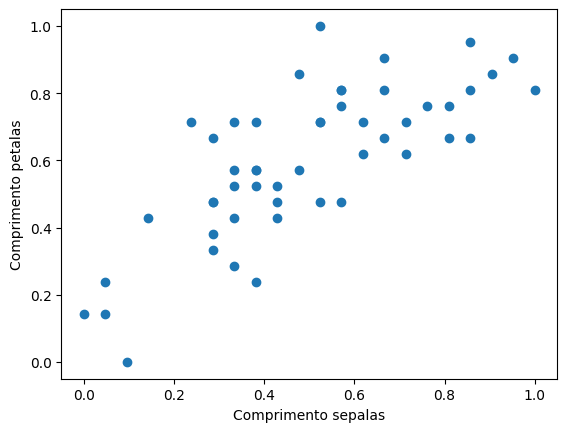

In [ ]:
plt.scatter(x_train,y_train)
plt.xlabel('Comprimento sepalas')
plt.ylabel('Comprimento petalas')

In [ ]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [ ]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428571],
       [1.        , 0.95238095],
       [1.        , 0.28571429],
       [1.        , 0.76190476],
       [1.        , 0.38095238],
       [1.        , 0.66666667],
       [1.        , 0.        ],
       [1.        , 0.80952381],
       [1.        , 0.14285714],
       [1.        , 0.04761905],
       [1.        , 0.47619048],
       [1.        , 0.52380952],
       [1.        , 0.57142857],
       [1.        , 0.33333333],
       [1.        , 0.85714286],
       [1.        , 0.33333333],
       [1.        , 0.42857143],
       [1.        , 0.61904762],
       [1.        , 0.33333333],
       [1.        , 0.47619048],
       [1.        , 0.57142857],
       [1.        , 0.66666667],
       [1.        , 0.57142857],
       [1.        , 0.71428571],
       [1.        , 0.80952381],
       [1.        , 0.9047619 ],
       [1.        , 0.85714286],
       [1.        , 0.52380952],
       [1.        , 0.38095238],
       [1.

In [ ]:
class Net():
    def __init__(self, n_in, n_out):
        self.w = np.random.uniform(-0.1,0.1,(n_out,n_in)) #inicialização dos parâmetros

    def forward(self, x_bias):
        return x_bias.dot(self.w.T)

In [ ]:
model = Net(2,1) # duas entradas (1 + x0) e uma saída y_pred

In [ ]:
xin = np.random.randn(4,2) # 4 amostras, 2 entradas (1 + x0)
ypred = model.forward(xin)
ypred

array([[-0.09602795],
       [ 0.0661236 ],
       [-0.06857828],
       [-0.05573871]])

1.Modifique o laço do treinamento via gradiente descendente para **guardar em uma lista**, o valor da perda no final de cada época. Após o treinamento, **plote o valor da perda em função da época**

In [ ]:
num_epochs = 100
learning_rate = 0.5

loss_history = [] # Lista para guardar o valor da perda em cada época

for epoch in range(num_epochs):

    # forward - predict
    y_pred = model.forward(x_train_bias)

    #loss cálculo da função de perda
    loss = np.square(y_pred - y_train).mean()
    loss_history.append(loss) # Guardar a perda na lista

    # cálculo do gradiente pelas derivadas parciais
    w_grad = (2.0/n_samples) * (x_train_bias.T).dot(x_train_bias.dot(model.w.T) - y_train)

    # gradiente descendente
    model.w = model.w - learning_rate * w_grad.T

    # # verbose
    # if (epoch+1) % 1 == 0:
    #     print('Epoch[{}/{}], loss: {:.6f}'
    #           .format(epoch+1, num_epochs, loss))

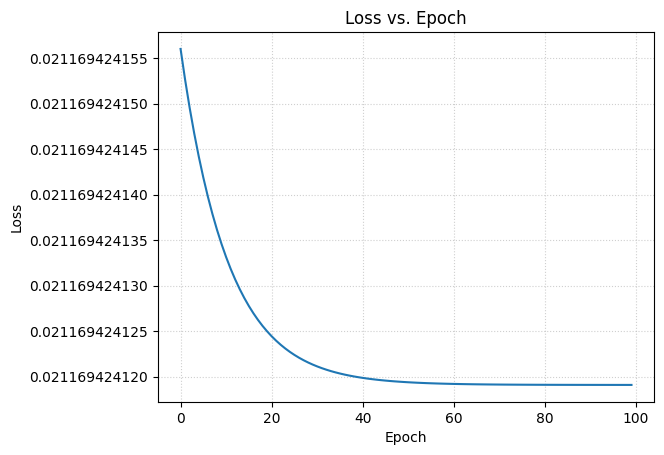

In [ ]:
plt.plot(range(num_epochs), loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.12f'))
plt.title('Loss vs. Epoch')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

2.Calcule o valor da perda (MSE) da rede com os parâmetros inicializados, sem serem treinados.

In [ ]:
model_untrained = Net(2,1) # Re-initialize the model to get untrained parameters
y_pred_untrained = model_untrained.forward(x_train_bias)
loss2 = np.square(y_pred_untrained - y_train).mean()
print(f"MSE sem treino: {loss2:.12f}")

MSE sem treino: 0.444765437314


3.Coloque os valores dos pesos da solução ótima analítica no modelo da rede e calcule o valor da perda (MSE) e compare com o valor da perda obtida pelo método da otimização via gradiente descendente.

In [ ]:
y_pred = model.forward(x_train_bias)

In [ ]:
loss = np.square(y_pred - y_train).mean()
loss

np.float64(0.021169424119099504)

In [ ]:
x = x_train_bias
y = y_train
w_opt = (np.linalg.inv((x.T).dot(x)).dot(x.T)).dot(y)
print(w_opt.T)

[[0.26134159 0.68646976]]


In [ ]:
model_optimal = Net(2, 1)
model_optimal.w = w_opt.T
y_pred_optimal = model_optimal.forward(x_train_bias)
mse_optimal = np.square(y_pred_optimal - y_train).mean()
print(f"MSE usando pesos analiticos: {mse_optimal:.15f}")
print(f"MSE com gradiente descendente: {loss:.15f}")

MSE usando pesos analiticos: 0.021169424119097
MSE com gradiente descendente: 0.021169424119100


Como esperado o MSE usando Gradiente Descendente deu um valor ligeiramente maior, por ser um algoritmo de aproximação numérica, ele "nunca" chegara exatamente no resultado que utiliza a Solução Ótima Analítica.